## Submission 5. Proportion of change-of-mind trials that have remote theta content vs local long theta 

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import pickle
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import ranksums
import seaborn as sns
import copy

In [3]:
from spyglass.shijiegu.Analysis_SGU import get_linearization_map

from spyglass.shijiegu.Analysis_SGU import TrialChoice, DecodeIngredients, DecodeResults2D, ChangeofMind, ChangeofMindTheta, DecodeResultsLinear
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.decoding.v0.visualization import make_single_environment_movie
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day
from spyglass.shijiegu.changeOfMind_triggered import select_subset_helper_position
from spyglass.shijiegu.changeOfMind_remote import find_posterior_sum_segment, find_remote_theta_animal_new
from spyglass.shijiegu.changeOfMind_remote_interval import find_remote_theta_animal, load_remote_animal
from spyglass.shijiegu.changeOfMind_figures.figure4_counting import count_trials

[2026-04-27 09:23:41,910][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[09:23:56][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[09:23:56][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[09:23:56][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[09:23:56][WARNING] Spyglass: Deprecation: this class has b

### Input parameter

In [4]:
parameter_name_long_theta = "params_both_max_segment_run_time_2_state"
parameter_name_remote = "params_both_max_run_time_2_state"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.2
sd = 6
hpd = False

local_parameter = f"dur_{minimum_duration_long}_sd_{sd}_hpd{hpd}"
remote_parameter = f"dur_{minimum_duration_remote}_sum_{min_posterior}"

### Make data

In [5]:
list_of_days_animals, success = {}, {}

animal = "molly"
list_of_days_animals[animal]  = ['20220415','20220416','20220417','20220418','20220419','20220420']

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']

In [6]:
success = {}
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'

def get_file_name(animal, parameter_name_remote, parameter_name_long_theta, local_parameter, remote_parameter):
    save_name = f"figure4_counting_{animal}_remote_{parameter_name_remote}_long_{parameter_name_long_theta}_{local_parameter}_{remote_parameter}"
    file_path = output_folder + save_name + '.pkl'
    return file_path

In [9]:
### Run this for data export to Dandi purpose only.
import os
import datajoint as dj

from spyglass.common.common_usage import Export, ExportSelection
paper_key = {"paper_id": "Gu2026"}

ExportSelection().start_export(**paper_key, analysis_id="ephys_proportion_counting")

[09:25:22][INFO] Spyglass: Starting {'export_id': 94}
INFO:spyglass:Starting {'export_id': 94}


In [10]:
success = {}
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'

def get_file_name(animal, parameter_name_remote, parameter_name_long_theta, local_parameter, remote_parameter):
    save_name = f"figure4_counting_{animal}_remote_{parameter_name_remote}_long_{parameter_name_long_theta}_{local_parameter}_{remote_parameter}"
    file_path = output_folder + save_name + '.pkl'
    return file_path

data_animals = {}
use_1d = 1
for animal in ["molly", "eliot", "julio", "klein", "lewis"]:
    (theta_long_ratio, theta_remote_ratio,
     theta_either_ratio, theta_both_ratio, com_num) = count_trials(
         animal, list_of_days_animals[animal],
         parameter_name_long_theta, local_parameter,
         parameter_name_remote, remote_parameter,
         proportion = 0.1)
    
    data_animals[animal] = {}
    data_animals[animal]["long_theta_ratio"] = theta_long_ratio
    data_animals[animal]["remote_ratio"] = theta_remote_ratio
    data_animals[animal]["either_ratio"] = theta_either_ratio
    data_animals[animal]["both_ratio"] = theta_both_ratio

    file_path = get_file_name(animal, parameter_name_remote, parameter_name_long_theta, local_parameter, remote_parameter)
    
    with open(file_path, 'wb') as file:
        pickle.dump(data_animals[animal], file, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Data successfully pickled and saved to {file_path}")

    success[animal] = True
    

molly20220415_.nwb
molly20220416_.nwb
molly20220417_.nwb
molly20220418_.nwb
molly20220419_.nwb
molly20220420_.nwb
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_molly_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl
eliot20221018_.nwb
eliot20221019_.nwb
eliot20221020_.nwb
eliot20221021_.nwb
eliot20221022_.nwb
eliot20221023_.nwb
eliot20221024_.nwb
eliot20221025_.nwb
eliot20221026_.nwb
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_eliot_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl
julio20230731_.nwb
julio20230801_.nwb
julio20230802_.nwb
julio20230803_.nwb
julio20230804_.nwb
julio20230805_.nwb
julio20230806_.nwb
julio20230807_.nwb
julio20230808_.nwb
julio20230809_.nwb
julio20230810_.nwb
julio20230811_.nwb
Data succ

In [11]:
success

{'molly': True, 'eliot': True, 'julio': True, 'klein': True, 'lewis': True}

In [12]:
ExportSelection().stop_export(**paper_key, analysis_id="ephys_proportion_counting")

In [50]:
from matplotlib.colors import Normalize
from scipy import stats
import starbars
import matplotlib as mpl
cmap = mpl.colormaps['cool']

### Load and plot

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_molly_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_eliot_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_julio_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_klein_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysi

(-0.2, 5.0)

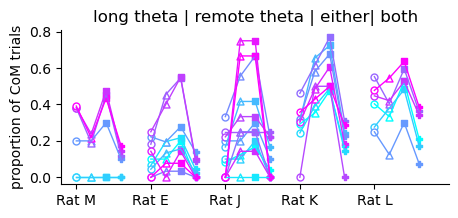

In [10]:
parameter_name_long_theta = "params_both_max_segment_run_time_2_state"
parameter_name_remote = "params_both_max_run_time_2_state"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.2
sd = 6
hpd = False

local_parameter = f"dur_{minimum_duration_long}_sd_{sd}_hpd{hpd}"
remote_parameter = f"dur_{minimum_duration_remote}_sum_{min_posterior}"

output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'


fig, axes = plt.subplots(1, 1, figsize=(5, 2),sharey = True)

animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]
for animal in animals:

    file_path = get_file_name(animal, parameter_name_remote, parameter_name_long_theta, local_parameter, remote_parameter)
    
    with open(file_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Successfully loaded data from '{file_path}':")

    long_ratio = loaded_data["long_theta_ratio"]
    remote_ratio = loaded_data["remote_ratio"]
    either_ratio = loaded_data["either_ratio"]
    both_ratio = loaded_data["both_ratio"]

    dates_to_plot = list_of_days_animals[animal]

    norm = Normalize(vmin=0, vmax=len(dates_to_plot)-1)

    dot_size = 25
    for ind in range(len(dates_to_plot)):
        
        axes.scatter(animal_ind, long_ratio[ind], edgecolor = cmap(norm(ind)), facecolor = 'white', s = dot_size, marker = "o")
        axes.scatter(animal_ind+0.2, remote_ratio[ind], edgecolor = cmap(norm(ind)), facecolor = 'white', s = dot_size, marker = "^")
        axes.scatter(animal_ind+0.4, either_ratio[ind], color = cmap(norm(ind)), s = dot_size, marker = "s")
        axes.scatter(animal_ind+0.6, both_ratio[ind], color = cmap(norm(ind)), s = dot_size, marker = "P")
        axes.plot(np.array([0,0.2,0.4,0.6]) + animal_ind,[long_ratio[ind],
                                                  remote_ratio[ind],
                                                  either_ratio[ind],
                                                  both_ratio[ind]],color = cmap(norm(ind)),linewidth = 1)

    #### add stats
    # logratio1 = np.log(either_ratio)
    # logratio2 = np.log(both_ratio)
    # logratio1[np.isinf(logratio1)] = -5
    # logratio2[np.isinf(logratio2)] = -5
    # t_statistic, p_value = stats.ttest_rel(logratio1,logratio2) #stats.ranksums(logratio1,logratio)#stats.ttest_rel(logratio1,logratio2)
    # print("p_value",p_value)
    # if p_value < 0.05:
    #     starbars.draw_annotation([(animal_ind + 0.4, animal_ind + 0.6, np.round(p_value, 4))])
    ########
    
    animal_ind += 1


axes.set_xticks(np.arange(len(animals)));
axes.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
axes.set_xlim([-1,len(animals) + 1]);
axes.set_title("long theta | remote theta | either| both")
axes.set_ylabel("proportion of CoM trials")
axes.spines[['right', 'top']].set_visible(False)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/"
#plt.savefig(file_path + "theta_content_counting.pdf",bbox_inches='tight')
#plt.savefig(file_path + "theta_content_counting.png",bbox_inches='tight')

axes.set_xlim([-0.2,len(animals)])

### a smaller plot

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_molly_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_eliot_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_julio_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_klein_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysi

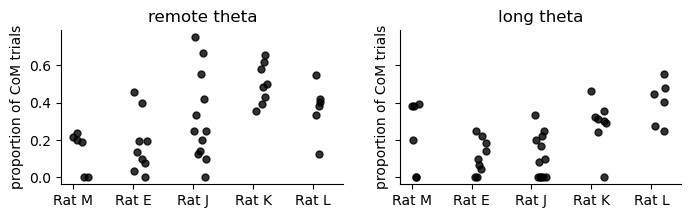

In [9]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'

use_1d = 1
fig, axes = plt.subplots(1, 2, figsize=(8, 2),sharey = True)

animal_ind = 0

animals = ["molly","eliot","julio","klein","lewis"]
for animal in animals:

    file_path = get_file_name(animal, parameter_name_remote, parameter_name_long_theta,local_parameter, remote_parameter)
    
    with open(file_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Successfully loaded data from '{file_path}':")

    long_ratio = loaded_data["long_theta_ratio"]
    remote_ratio = loaded_data["remote_ratio"]
    either_ratio = loaded_data["either_ratio"]
    both_ratio = loaded_data["both_ratio"]

    dates_to_plot = list_of_days_animals[animal]

    norm = Normalize(vmin=0, vmax=len(dates_to_plot)-1)

    dot_size = 25
    for ind in range(len(dates_to_plot)):
        
        #axes.scatter(animal_ind, long_theta_ratio[ind], edgecolor = cmap(norm(ind)), facecolor = 'white', s = dot_size, marker = "o")
        #axes.scatter(animal_ind+0.2, remote_ratio[ind], edgecolor = cmap(norm(ind)), facecolor = 'white', s = dot_size, marker = "^")
        axes[0].scatter(animal_ind+np.random.rand()*0.25, remote_ratio[ind], color = "k", alpha = 0.8, s = dot_size)
        axes[1].scatter(animal_ind+np.random.rand()*0.25, long_ratio[ind], color = "k", alpha = 0.8, s = dot_size)
        #axes.scatter(animal_ind+0.6, intersection_ratio[ind], color = cmap(norm(ind)), s = dot_size, marker = "P")
 
    
    animal_ind += 1

axe = axes[0]
#axes.axhline(y = 1, color=[0.6,0.6,0.6], linestyle='--')
axe.set_xticks(np.arange(len(animals)));
axe.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
axe.set_title("remote theta")
axe.set_ylabel("proportion of CoM trials")
axe.spines[['right', 'top']].set_visible(False)
axe.set_xlim([-0.2,len(animals)-0.5])

axe = axes[1]
#axes.axhline(y = 1, color=[0.6,0.6,0.6], linestyle='--')
axe.set_xticks(np.arange(len(animals)));
axe.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
axe.set_title("long theta")
axe.set_ylabel("proportion of CoM trials")
axe.spines[['right', 'top']].set_visible(False)
axe.set_xlim([-0.2,len(animals)-0.5])

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/"
plt.savefig(file_path + "counting_remote.pdf",bbox_inches='tight', transparent=True)
plt.savefig(file_path + "counting_remote.png",bbox_inches='tight', transparent=True)



### Stats for changes over days

In [51]:
color_by_rat = {"eliot": "C0","molly":"C2","lewis":"C4","julio":"C1","klein":"deepskyblue"}
import statsmodels.api as sm
import numpy.matlib as ml
import matplotlib.patheffects as PathEffects

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_molly_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
pvalue 0.025208268067580853
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_eliot_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
pvalue 0.9324506203287618
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_julio_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
pvalue 0.018668127094008197
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_klein_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_

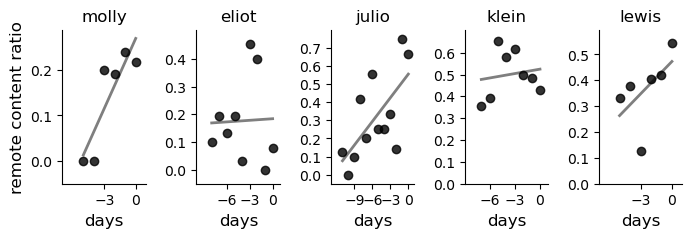

In [59]:
fig, axes = plt.subplots(1, 5, figsize=(8, 2))

animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]
for animal in animals:

    file_path = get_file_name(animal, parameter_name_remote, parameter_name_long_theta,local_parameter, remote_parameter)
    
    with open(file_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Successfully loaded data from '{file_path}':")

    long_ratio = loaded_data["long_theta_ratio"]
    remote_ratio = loaded_data["remote_ratio"]
    either_ratio = loaded_data["either_ratio"]
    both_ratio = loaded_data["both_ratio"]

    days = list_of_days_animals[animal]

    norm = Normalize(vmin=0, vmax=len(days)-1)
        
    x_indeces = np.arange(len(days))

    ratios = remote_ratio#both_ratio
    axes[animal_ind].scatter(x_indeces - x_indeces[-1], ratios,
                 color = "k", alpha = 0.8, label = f"Rat {animal[0].upper()}")
    #axes.plot(x_indeces - x_indeces[-1], ratios, color = color_by_rat[animal.lower()[:5]])
    X = sm.add_constant(x_indeces)

    # 3. Create and fit the OLS (Ordinary Least Squares) model
    model = sm.OLS(ratios, X)
    results = model.fit()

    X_pred = np.linspace(x_indeces[0],x_indeces[-1],20)
    X_pred = sm.add_constant(X_pred)
    X_plot = X_pred[:,-1] - x_indeces[-1]
    Y_pred = results.predict(X_pred)
    axes[animal_ind].plot(X_plot, Y_pred, color="k", linewidth = 2, alpha = 0.5) #color_by_rat[animal.lower()[:5]]
    pvalue = results.pvalues[1]
    mid_ind = int(len(X_plot)/2)
    print("pvalue", pvalue)
    if pvalue <= 0.001:
        txt = axes[animal_ind].set_title(animal+"\n**")
    elif pvalue <= 0.01:
        txt = axes[animal_ind].set_title(animal+"\n*")
    #else:
    axes[animal_ind].set_title(animal)
    #txt.set_path_effects([PathEffects.withStroke(linewidth=5, foreground='w')])

    # log scale
    # axes[animal_ind].set_yscale('log')
    
    # legend = axes.legend(edgecolor = 'k',fontsize = 12, loc='upper left',bbox_to_anchor=(1.05, 0.8))
    # # Get the legend frame (which is a Rectangle object)
    # frame = legend.get_frame()
    # # Set the linewidth of the legend frame
    # frame.set_linewidth(1)

    #axes[animal_ind].axhline(y = 2, color=[0.6,0.6,0.6], linestyle='--')

    xaxis = x_indeces - x_indeces[-1]
    axes[animal_ind].set_xticks(xaxis[::-1][::3]);
    axes[animal_ind].set_xlim([np.min(xaxis)-2,np.max(xaxis) +1])
    axes[animal_ind].set_ylim([np.min(ratios)-0.05,np.max(ratios) +0.05])
    #axes.set_xticklabels(["Rat " + animal[0] for animal in animals]);
    #axes.set_xlim([-1,len(animals) + 1]);
    #axes[animal_ind].set_ylim([1/1.5,4]);
    #axes.set_title("All behavior")
    if animal_ind == 0:
        axes[animal_ind].set_ylabel("remote content ratio", fontsize = 12)
    else:
        axes[animal_ind].set_ylabel("")
    axes[animal_ind].set_yticks(np.arange(0,np.max(ratios),0.1))
        
    axes[animal_ind].set_xlabel("days", fontsize = 12)
    axes[animal_ind].spines[['right', 'top']].set_visible(False)
    axes[animal_ind].margins(x=0.05, y=0.05)
    animal_ind += 1

plt.subplots_adjust(
    wspace=0.6,
    hspace=0.2
)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/theta_counting_stats"
plt.savefig(file_path + ".pdf",bbox_inches='tight')
plt.savefig(file_path + ".png")

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_molly_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_eliot_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_julio_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_klein_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysi

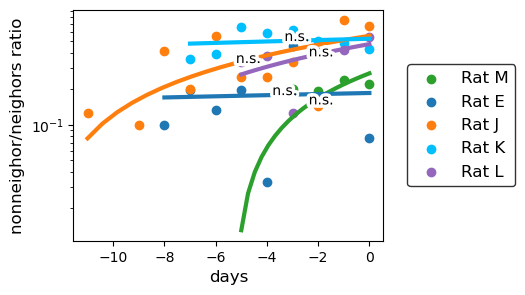

In [14]:
fig, axes = plt.subplots(1, 1, figsize=(4, 3))

animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]
for animal in animals:

    file_path = get_file_name(animal, parameter_name_remote, parameter_name_long_theta,local_parameter, remote_parameter)
    
    with open(file_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Successfully loaded data from '{file_path}':")

    long_ratio = loaded_data["long_theta_ratio"]
    remote_ratio = loaded_data["remote_ratio"]
    either_ratio = loaded_data["either_ratio"]
    both_ratio = loaded_data["both_ratio"]

    days = list_of_days_animals[animal]

    norm = Normalize(vmin=0, vmax=len(days)-1)
        
    x_indeces = np.arange(len(days))

    ratios = remote_ratio#both_ratio
    axes.scatter(x_indeces - x_indeces[-1], ratios,
                 color = color_by_rat[animal.lower()[:5]], label = f"Rat {animal[0].upper()}")
    #axes.plot(x_indeces - x_indeces[-1], ratios, color = color_by_rat[animal.lower()[:5]])
    X = sm.add_constant(x_indeces)

    # 3. Create and fit the OLS (Ordinary Least Squares) model
    model = sm.OLS(ratios, X)
    results = model.fit()

    X_pred = np.linspace(x_indeces[0],x_indeces[-1],20)
    X_pred = sm.add_constant(X_pred)
    X_plot = X_pred[:,-1] - x_indeces[-1]
    Y_pred = results.predict(X_pred)
    axes.plot(X_plot, Y_pred, color=color_by_rat[animal.lower()[:5]], linewidth = 3)
    pvalue = results.pvalues[1]
    mid_ind = int(len(X_plot)/2)
    if pvalue <= 0.001:
        txt = axes.text(X_plot[mid_ind], Y_pred[mid_ind], "**", color = 'k')
    elif pvalue <= 0.01:
        txt = axes.text(X_plot[mid_ind], Y_pred[mid_ind], "*", color = 'k')
    else:
        txt = axes.text(X_plot[mid_ind], Y_pred[mid_ind], "n.s.", color = 'k')
    txt.set_path_effects([PathEffects.withStroke(linewidth=5, foreground='w')])


    #### add stats
    # t_statistic, p_value = stats.ttest_rel(P_neighors, P_nonneighors)
    # print("p_value",p_value)
    # axes.text(animal_ind + 0.1,5,str(np.round(p_value, 4)))
    ########

    animal_ind += 1

# log scale
axes.set_yscale('log')
legend = axes.legend(edgecolor = 'k',fontsize = 12, loc='upper left',bbox_to_anchor=(1.05, 0.8))
# Get the legend frame (which is a Rectangle object)
frame = legend.get_frame()
# Set the linewidth of the legend frame
frame.set_linewidth(1)


#axes.axhline(y = 1, color=[0.6,0.6,0.6], linestyle='--')
#axes.set_xticks(np.arange(len(animals)));
#axes.set_xticklabels(["Rat " + animal[0] for animal in animals]);
#axes.set_xlim([-1,len(animals) + 1]);
#axes.set_ylim([1/1.5,4]);
#axes.set_title("All behavior")
axes.set_ylabel("nonneighor/neighors ratio", fontsize = 12)
axes.set_xlabel("days", fontsize = 12)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure4/theta_counting_stats"
plt.savefig(file_path + ".pdf",bbox_inches='tight')
plt.savefig(file_path + ".png")

### Mixed linear effect

In [13]:
import numpy.matlib as ml
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm

In [28]:
either_ratio

array([0.52631579, 0.48275862, 0.3       , 0.59574468, 0.52631579,
       0.63636364])

In [67]:
feature_names = ["previous", "previously_rewarded", "future", "future_correct", "same side", "switch side"]

animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]

GLM_x = []
GLM_y = []
for animal in animals:
    file_path = get_file_name(animal, parameter_name_remote, parameter_name_long_theta, local_parameter, remote_parameter)
    
    with open(file_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Successfully loaded data from '{file_path}':")

    long_ratio = loaded_data["long_theta_ratio"]
    remote_ratio = loaded_data["remote_ratio"]
    either_ratio = loaded_data["either_ratio"]
    both_ratio = loaded_data["both_ratio"]
    days = list_of_days_animals[animal]

    x_indeces = np.arange(len(days)).reshape((-1,1))

    features_all = x_indeces - x_indeces[-1]
    response_all = either_ratio #remote_ratio

    # GLM process
    X = np.vstack(features_all).astype("int") #reshape
    
    animal_category = np.array([a == animal for a in animals]).reshape((1,-1))
    X_animal_category = ml.repmat(animal_category, np.shape(X)[0], 1)
    X = np.hstack((X_animal_category, X))
    
    Y = np.vstack([np.array(r).reshape((-1,1))for r in response_all]) #reshape

    GLM_x.append(X)
    GLM_y.append(Y)
    
GLM_x = np.vstack(GLM_x)
GLM_y = np.vstack(GLM_y)

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_molly_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_eliot_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_julio_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/figure4_counting_klein_remote_params_both_max_run_time_2_state_long_params_both_max_segment_run_time_2_state_dur_0.03_sd_6_hpdFalse_dur_0.02_sum_0.2.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysi

In [68]:
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_x[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["days from peak"] = GLM_x[:,len(animals)]

X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_y

"""a) Mixed Linear Effect"""
ols_model = sm.OLS(y,X)
ols_result1 = ols_model.fit()

print("Mixed Linear Effect \n",ols_result1.summary())

Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.472
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                     6.257
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           0.000303
Time:                        08:58:11   Log-Likelihood:                 16.730
No. Observations:                  41   AIC:                            -21.46
Df Residuals:                      35   BIC:                            -11.18
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.4

In [34]:
def model2numbers(ols_result):
    coef_names = ols_result.params.keys()
    coef_est = np.array(ols_result.params)
    pvalues = ols_result.pvalues
    CI = ols_result.conf_int(alpha=0.05)
    #yerr = np.vstack((np.array(CI[0]).reshape((1,-1)), np.array(CI[1]).reshape((1,-1)))) # 2 x coefficients

    coef_names_subset_ind = ["Rat" not in name for name in coef_names]
    coef_names = np.array(coef_names)[coef_names_subset_ind]
    coef_est = coef_est[coef_names_subset_ind]
    pvalues = pvalues[coef_names_subset_ind]
    CI = CI.loc[coef_names]

    return ols_result.params, coef_names, coef_est, pvalues, CI#, yerr

1.98 0.03


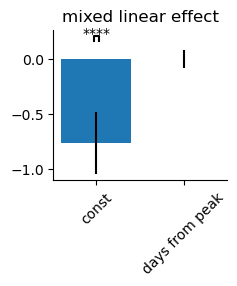

In [35]:
# 4. Create the bar graph using matplotlib

fig, axes = plt.subplots(1,1,figsize=(3, 3.5))

#### axis 0
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(ols_result1)
axes.bar(coef_names, coef_est, error_kw=dict(color='k'))
for coef_name in coef_names:
    axes.plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes)

axes.set_xticks(np.arange(len(coef_names)))
axes.set_xticklabels(coef_names, rotation=45)
axes.set_title("mixed linear effect")
axes.spines[['right', 'top']].set_visible(False)

fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure4/theta_counting_stats_beta_coef"
plt.savefig(file_path +'.pdf',dpi=300,bbox_inches='tight')

### End here

### Start here for loading remote parsing

In [193]:
animal = 'klein'

In [194]:
loaded_data = load_remote_animal_figure4(
        animal, list_of_days_animals[animal],
        encoding_set_animals[animal],
        classifier_param_name_animals[animal],
        proportion = 0.1, use_1d = 1)
    
(all_info_animal, info_animal,
     time_intervals_animal, arm_identities_animal
        ) = (loaded_data['all_info_animal'], loaded_data['info_animal'],
             loaded_data['time_intervals_animal'], loaded_data['arm_identities_animal'])

(all_info_animal_control, info_animal_control,
     time_intervals_animal_control, arm_identities_animal_control
        ) = (loaded_data['all_info_animal_control'], loaded_data['info_animal_control'],
             loaded_data['time_intervals_animal_control'], loaded_data['arm_identities_animal_control'])

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/klein_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20231101_20231111_p0.1_use1d1.pkl':


In [192]:
info_animal

[['julio20230802_.nwb', '06_Seq2Session3', [69]],
 ['julio20230803_.nwb', '08_Seq2Session4', [51, 51]],
 ['julio20230803_.nwb', '10_Seq2Session5', [9]],
 ['julio20230803_.nwb', '12_Seq2Session6', [13, 13]],
 ['julio20230803_.nwb', '12_Seq2Session6', [52]],
 ['julio20230804_.nwb', '04_Seq2Session2', [70, 70]],
 ['julio20230805_.nwb', '04_Seq2Session2', [20]],
 ['julio20230805_.nwb', '04_Seq2Session2', [27, 27, 27]],
 ['julio20230805_.nwb', '06_Seq2Session3a', [17]],
 ['julio20230808_.nwb', '02_Seq2Session1', [67, 67, 67]],
 ['julio20230808_.nwb', '08_Seq2Session4', [27]],
 ['julio20230809_.nwb', '02_Seq2Session1', [26, 26, 26, 26, 26, 26]],
 ['julio20230810_.nwb', '04_Seq2Session2', [51]],
 ['julio20230810_.nwb', '06_Seq2Session3', [12]],
 ['julio20230810_.nwb', '08_Seq2Session4', [18]],
 ['julio20230810_.nwb', '08_Seq2Session4', [73]],
 ['julio20230811_.nwb', '09_Seq2Session5', [17]]]

In [ ]:
"""
['julio20230803_.nwb', '08_Seq2Session4', [51, 51]],
['julio20230803_.nwb', '10_Seq2Session5', [9]],
['julio20230803_.nwb', '12_Seq2Session6', [13, 13]],
['julio20230803_.nwb', '12_Seq2Session6', [52]],
['julio20230808_.nwb', '02_Seq2Session1', [67, 67, 67]],
['julio20230808_.nwb', '08_Seq2Session4', [27]],


['eliot20221020_.nwb', '12_Seq2Session6', [19]],
 ['eliot20221020_.nwb', '12_Seq2Session6', [28]],
 ['eliot20221020_.nwb', '12_Seq2Session6', [60]],
 ['eliot20221021_.nwb', '08_Seq2Session4', [60]],
 ['eliot20221021_.nwb', '08_Seq2Session4', [78]],
"""

### End here

In [126]:
def plot(posterior_arm_pre, posterior_arm_control_pre, arm_position, ax, list_of_days, labels):
    posterior_arm_pre_np = np.array(posterior_arm_pre).squeeze()
    posterior_arm_control_pre_np = np.array(posterior_arm_control_pre).squeeze()
    
    mean_pre = np.nanmean(posterior_arm_pre_np, axis = 0)
    sd_pre = np.nanstd(posterior_arm_pre_np, axis = 0)
    
    mean_pre_control = np.nanmean(posterior_arm_control_pre_np, axis = 0)
    sd_pre_control = np.nanstd(posterior_arm_control_pre_np, axis = 0)
    
    for posterior_arm_ in posterior_arm_pre_np:
        ax.plot(np.arange(len(posterior_arm_)),posterior_arm_, 'C1', alpha = 0.2, linewidth = 1)
    
    for posterior_arm_ in posterior_arm_control_pre_np:
        ax.plot(np.arange(len(posterior_arm_)),posterior_arm_, 'C0', alpha = 0.2, linewidth = 1)

    # mean trace
    ax.plot(np.arange(len(mean_pre)), mean_pre, linewidth = 3, color = 'C1', zorder = 100, label = labels[0])
    ax.plot(np.arange(len(mean_pre_control)), mean_pre_control, linewidth = 3, color = 'C0', zorder = 99, label = labels[1])

    # shading
    CI_upper = (mean_pre + sd_pre).reshape((-1,1))
    CI_upper = np.min(np.hstack([CI_upper, np.ones_like(CI_upper)]),axis = 1)

    CI_upper_control = ( mean_pre_control + sd_pre_control).reshape((-1,1))
    CI_upper_control = np.min(np.hstack([CI_upper_control, np.ones_like(CI_upper_control)]),axis = 1)
    
    ax.fill_between(np.arange(len(posterior_arm_)), mean_pre - sd_pre, CI_upper,
                    alpha = 0.4, color = 'C1', zorder = 200, label = labels[0])
    ax.fill_between(np.arange(len(posterior_arm_)), mean_pre_control - sd_pre_control, CI_upper_control,
                    alpha = 0.4, color = 'C0', zorder = 200, label = labels[1])

    ax.set_xticks(np.arange(len(posterior_arm_)))
    ax.set_xticklabels([str(int(np.round(p))) for p in np.mean(arm_position, axis = 1)])
    list_of_days_short = [d[4:8] for d in list_of_days]
    ax.set_title(f"{animal}\n{list_of_days_short}\nlocal posterior when the rat is in outer arm")
    ax.set_ylabel("probability")
    ax.set_xlabel("outer arm bins (10 cm)")
    ax.set_ylim([0,1.1])
    ax.legend()

### Load data

In [179]:
animal = "molly"
list_of_days = ["20220415","20220416","20220417","20220418","20220419","20220420"]

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'

data = load_remote_animal_figure7c(animal, list_of_days, encoding_set, classifier_param_name,
                                   proportion = 0.1, use_1d = 1)


NameError: name 'load_remote_animal_figure7c' is not defined

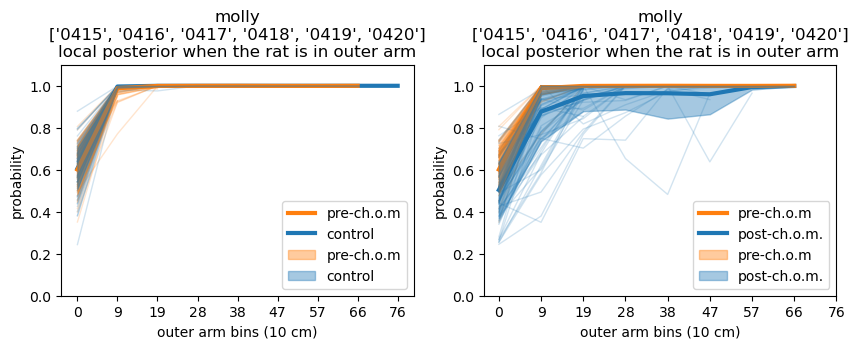

In [127]:
fig, axes = plt.subplots(1,2,figsize = (10,3))
plot(data["posterior_arm_pre"], data["posterior_arm_control_pre"], data["arm_position"], axes[0], list_of_days, ["pre-ch.o.m","control"])
plot(data["posterior_arm_pre"], data["posterior_arm_post"], data["arm_position"], axes[1],list_of_days, ["pre-ch.o.m","post-ch.o.m."])
